In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.1 Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

# 1.2 How many missing values per column?
# TODO: Compute and display titanic.isnull().sum()
print("="*50)
print("1.2 - Missing Values Count per Column")
print("="*50)
print(titanic.isnull().sum())

1.2 - Missing Values Count per Column
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


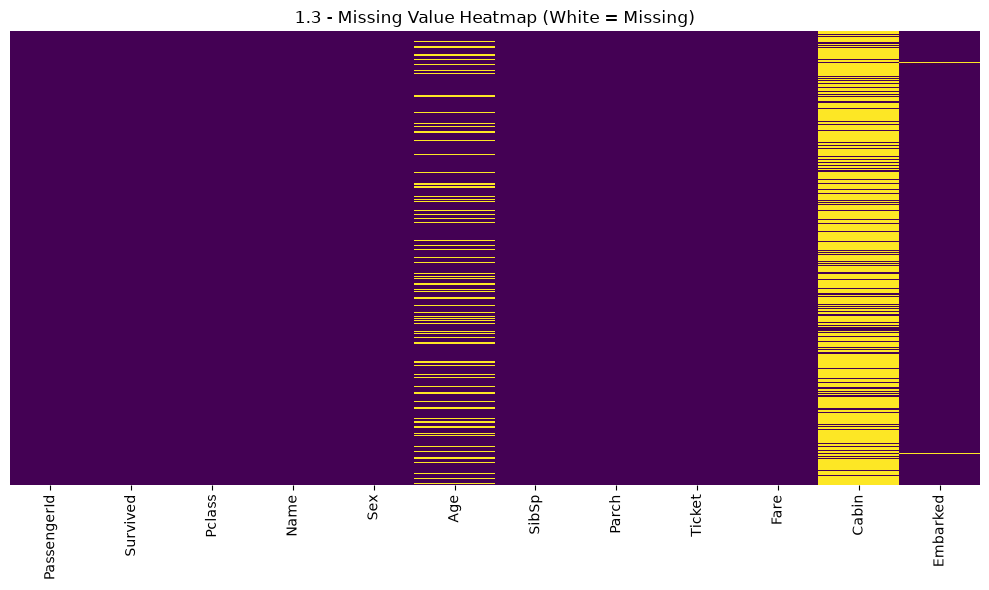

In [2]:
# 1.3 Visualize missingness with a heatmap
plt.figure(figsize=(10,6))
# TODO: use sns.heatmap(...) to show where data is missing
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('1.3 - Missing Value Heatmap (White = Missing)')
plt.tight_layout()
plt.show()

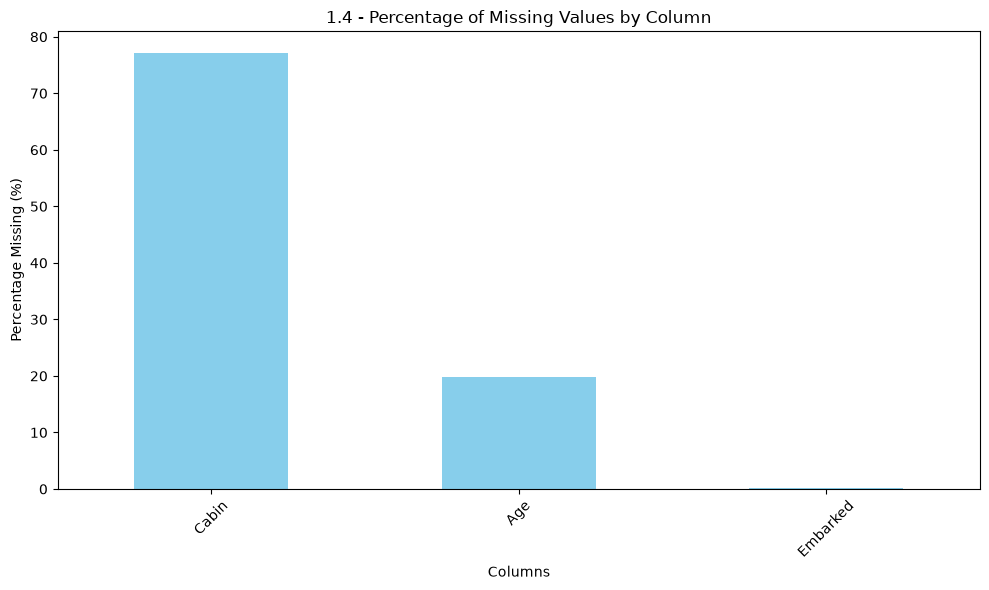


Missing Value Summary:
Cabin       77.104377
Age         19.865320
Embarked     0.224467
dtype: float64


In [3]:
# 1.4 Percentage of missing values by column (bar plot)
# TODO: calculate percentage and plot as a bar chart
missing_percentage = titanic.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar', color='skyblue')
plt.title('1.4 - Percentage of Missing Values by Column')
plt.ylabel('Percentage Missing (%)')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nMissing Value Summary:")
print(missing_percentage)

In [4]:
# Start from a copy
df = titanic.copy()

# 2.1 Drop columns with too many missing or irrelevant
# TODO: df = df.drop([...], axis=1)
df = df.drop(['Cabin', 'Ticket'], axis=1)
print("2.1 - Dropped 'Cabin' (77% missing) and 'Ticket' (not useful for prediction)")

2.1 - Dropped 'Cabin' (77% missing) and 'Ticket' (not useful for prediction)


In [5]:
# 2.2 Impute Age by median within each Pclass
# TODO: df['Age'] = df.groupby('Pclass')['Age'].transform(...)
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
print("2.2 - Imputed Age using median by Pclass")

2.2 - Imputed Age using median by Pclass


In [6]:
# 2.3 Create Age_missing indicator column
# TODO: df['Age_Missing'] = ...
df['Age_Missing'] = titanic['Age'].isnull().astype(int)
print("2.3 - Created indicator for passengers whose age was missing")

2.3 - Created indicator for passengers whose age was missing


In [7]:
# 2.4 Impute Embarked with mode
# TODO: df['Embarked'] = df['Embarked'].fillna(...)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("2.4 - Imputed Embarked with mode (most frequent value)")

2.4 - Imputed Embarked with mode (most frequent value)


In [8]:
# 2.5 Verify no more missing values
# TODO: df.isnull().sum()
print("\n2.5 - Final Missing Value Check:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


2.5 - Final Missing Value Check:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Missing    0
dtype: int64

Total missing values: 0


In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

features = ['Age','Fare']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3.1 Standardization (Z-score normalization)
std = StandardScaler()
# TODO: fit on X_train, transform both X_train and X_test
X_train_std = X_train.copy()
X_test_std = X_test.copy()
X_train_std[features] = std.fit_transform(X_train[features])
X_test_std[features] = std.transform(X_test[features])
print("3.1 - Applied StandardScaler (mean=0, std=1)")

3.1 - Applied StandardScaler (mean=0, std=1)


In [11]:
# 3.2 Min‑Max normalization
mms = MinMaxScaler()
# TODO: fit on X_train, transform both X_train and X_test
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()
X_train_norm[features] = mms.fit_transform(X_train[features])
X_test_norm[features] = mms.transform(X_test[features])
print("3.2 - Applied MinMaxScaler (values in [0, 1])")

3.2 - Applied MinMaxScaler (values in [0, 1])


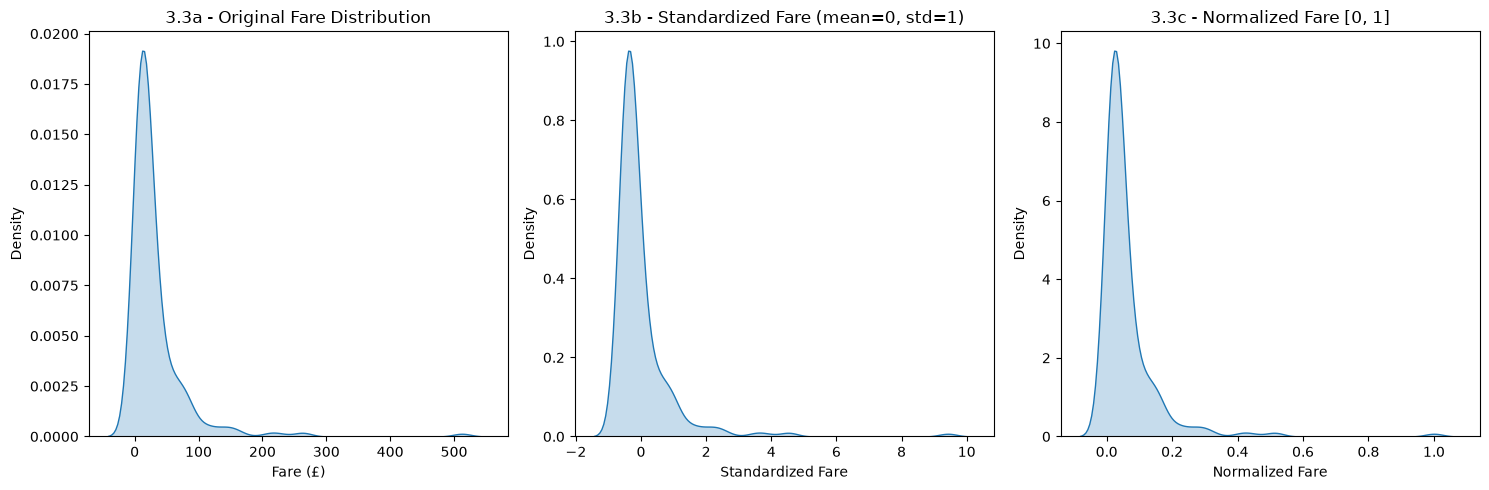

In [12]:
# 3.3 Plot distributions: original vs standardized vs normalized
plt.figure(figsize=(15,5))

plt.subplot(1, 3, 1)
sns.kdeplot(X_train['Fare'], label='Original', fill=True)
plt.title('3.3a - Original Fare Distribution')
plt.xlabel('Fare (£)')

plt.subplot(1, 3, 2)
sns.kdeplot(X_train_std['Fare'], label='Standardized', fill=True)
plt.title('3.3b - Standardized Fare (mean=0, std=1)')
plt.xlabel('Standardized Fare')

plt.subplot(1, 3, 3)
sns.kdeplot(X_train_norm['Fare'], label='Normalized', fill=True)
plt.title('3.3c - Normalized Fare [0, 1]')
plt.xlabel('Normalized Fare')

plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

X_cat = df[['Sex','Embarked']]

# 4.1 Label‑encode Sex
le = LabelEncoder()
# TODO: X_cat['Sex_le'] = ...
X_cat_encoded = X_cat.copy()
X_cat_encoded['Sex_le'] = le.fit_transform(X_cat['Sex'])
print("4.1 - Label Encoded Sex: male=0, female=1")
print(f"Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

4.1 - Label Encoded Sex: male=0, female=1
Mapping: {'female': np.int64(0), 'male': np.int64(1)}


In [14]:
# 4.2 One‑hot encode Embarked (drop first)
ohe = OneHotEncoder(sparse_output=False, drop='first')
# TODO: fit_transform Embarked and create a DataFrame with new columns
embarked_encoded = ohe.fit_transform(X_cat[['Embarked']])
embarked_cols = [f'Embarked_{c}' for c in ohe.categories_[0][1:]]
embarked_df = pd.DataFrame(embarked_encoded, columns=embarked_cols, index=X_cat.index)

# Combine all encoded features
X_encoded_final = pd.concat([X_cat_encoded[['Sex_le']], embarked_df], axis=1)

# Display your encoded features
# TODO: print head of resulting DataFrame
print("\n4.2 - One-Hot Encoded Embarked (drop first)")
print("Encoded Features (first 5 rows):")
print(X_encoded_final.head())

print(f"\nOne-Hot columns: {embarked_cols}")
print("Note: 'drop first' means we dropped one column to avoid multicollinearity")


4.2 - One-Hot Encoded Embarked (drop first)
Encoded Features (first 5 rows):
   Sex_le  Embarked_Q  Embarked_S
0       1         0.0         1.0
1       0         0.0         0.0
2       0         0.0         1.0
3       0         0.0         1.0
4       1         0.0         1.0

One-Hot columns: ['Embarked_Q', 'Embarked_S']
Note: 'drop first' means we dropped one column to avoid multicollinearity


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 5.1 Define transformers
num_features = ['Age','Fare']
cat_features = ['Sex','Embarked']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle any remaining missing values
    ('scaler', StandardScaler())                    # Scale numerical features
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing with mode
    ('onehot', OneHotEncoder(drop='first'))               # One-hot encode
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# 5.2 Create full pipeline with Logistic Regression
pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

# 5.3 Split raw data and train
X_full = df[num_features + cat_features]
y_full = df['Survived']
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# TODO: fit pipe on X_tr, y_tr
pipe.fit(X_tr, y_tr)

# TODO: predict on X_te, compute accuracy and print classification_report
y_pred = pipe.predict(X_te)

print("="*50)
print("5.3 - Logistic Regression Pipeline Results")
print("="*50)
print(f"Accuracy: {accuracy_score(y_te, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_te, y_pred))

5.3 - Logistic Regression Pipeline Results
Accuracy: 0.7799

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.70      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 6.1 Replace classifier in pipeline
tune_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# 6.2 Set up parameter grid
param_grid = {
    'clf__n_estimators': [50, 100],           # Number of trees
    'clf__max_depth': [None, 10],             # Tree depth (None = unlimited)
    'preproc__num__imputer__strategy': ['mean','median']  # Imputation strategy
}

grid = GridSearchCV(tune_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# TODO: fit grid on X_tr, y_tr
grid.fit(X_tr, y_tr)

# TODO: print best_params_ and best_score_
print("="*50)
print("6.2 - GridSearchCV Results")
print("="*50)
print(f"Best parameters: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.4f}")

# 6.3 Evaluate best estimator on test set
# TODO: grid.best_estimator_.score(X_te, y_te)
test_score = grid.best_estimator_.score(X_te, y_te)
print(f"Test set score with best parameters: {test_score:.4f}")

6.2 - GridSearchCV Results
Best parameters: {'clf__max_depth': 10, 'clf__n_estimators': 100, 'preproc__num__imputer__strategy': 'mean'}
Best cross-validation score: 0.7962
Test set score with best parameters: 0.7500


C:\Users\ST\AppData\Local\Temp\ipykernel_5868\492348623.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


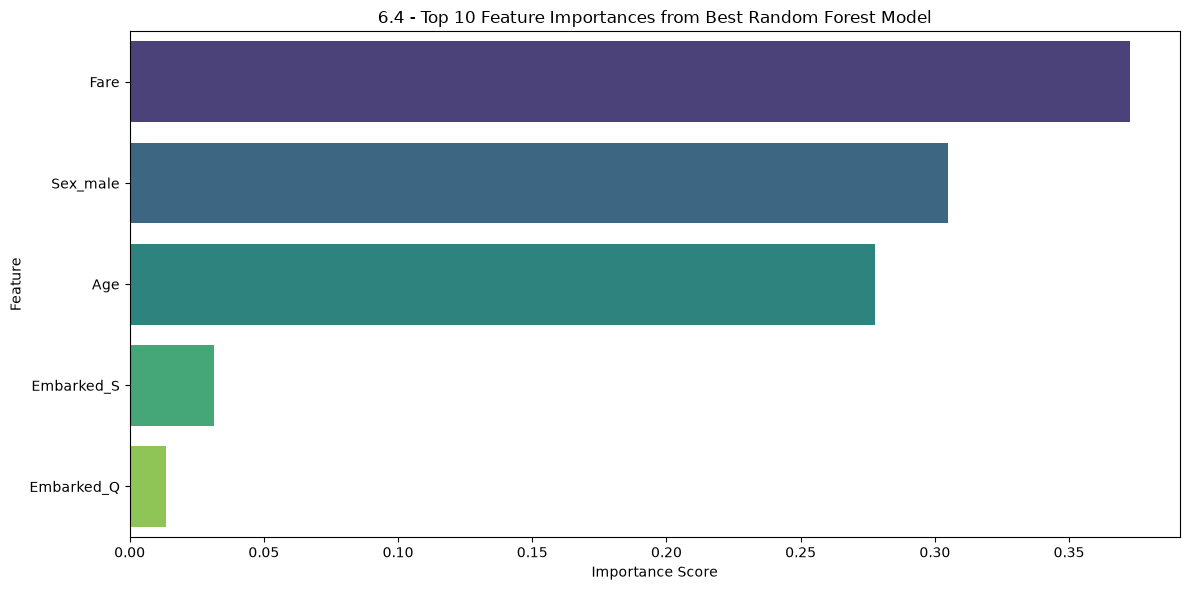


6.4 - Feature Importance Rankings:
      Feature  Importance
1        Fare    0.372690
2    Sex_male    0.304935
0         Age    0.277557
4  Embarked_S    0.031333
3  Embarked_Q    0.013485


In [17]:
# 6.4 (Bonus) If RandomForest gives feature_importances_, extract and plot the top 10
# Hint: use .named_steps['preproc'] to get transformer and get_feature_names_out

# First, get the best model
best_model = grid.best_estimator_

if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    # Get feature names
    preprocessor = best_model.named_steps['preproc']
    
    # Get one-hot encoded feature names
    ohe_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(['Sex', 'Embarked'])
    feature_names = np.concatenate([num_features, ohe_features])
    
    # Get importances
    importances = best_model.named_steps['clf'].feature_importances_
    
    # Create DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Plot top 10
    plt.figure(figsize=(12, 6))
    top_features = importance_df.head(10)
    sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
    plt.title('6.4 - Top 10 Feature Importances from Best Random Forest Model')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
    
    print("\n6.4 - Feature Importance Rankings:")
    print(importance_df)